In [1]:
# =============================================================================
# 14_test_scm_validation.ipynb
#
# PURPOSE
# =============================================================================
#
# Test whether feature-based Synthetic Control Method (SCM) can construct
# a credible counterfactual trajectory for each hurricane treatment site.
#
#
# INPUT DATA
# =============================================================================
#
# finals/
# └── biweekly_datasets/
#
#     ├── sentinel1/
#     │   ├── treatment/
#     │   └── counterfactual/
#     │
#     ├── sentinel2/
#     │   ├── treatment/
#     │   └── counterfactual/
#     │
#     └── biweekly_image_quality.csv
#
# Matching information:
#
# finals/
# └── daily_datasets/
#     └── selected_site_sample.csv
#
#
# TEMPORAL DESIGN
# =============================================================================
#
# P01-P08 = SCM TRAINING
#
#   Estimate donor weights using only untreated pre-hurricane information.
#
# P09-P10 = SCM VALIDATION
#
#   Do NOT re-estimate weights.
#   Predict the treated site's features using the weights estimated from P01-P08.
#
# P11-P20 = TREATMENT / EFFECT PERIOD
#
#   Once validation is satisfactory, use the same fixed weights to construct
#   the no-hurricane counterfactual.
#
#
# IMPORTANT
# =============================================================================
#
# This notebook first tests SCM validity.
#
# It does NOT use P09-P10 to estimate weights.
# It does NOT use P11-P20 to estimate weights.
#
#
# FEATURE-BASED WORKFLOW
# =============================================================================
#
# Biweekly TIFF
#      ↓
# Extract interpretable image features
#      ↓
# Site × period × feature dataset
#      ↓
# Standardize features using P01-P08 only
#      ↓
# Estimate SCM donor weights using P01-P08
#      ↓
# Freeze weights
#      ↓
# Validate on P09-P10
#      ↓
# Construct counterfactual P11-P20
#      ↓
# Actual - Synthetic = estimated feature effect
#
#
# SCM
# =============================================================================
#
# For treated site i:
#
#     X_it ≈ Σ_j w_j X_jt
#
# subject to:
#
#     w_j >= 0
#     Σ_j w_j = 1
#
#
# OUTPUT
# =============================================================================
#
# test/
# └── scm_validation/
#
#     ├── 01_extracted_features.csv
#     ├── 02_scm_weights.csv
#     ├── 03_training_fit.csv
#     ├── 04_validation_results.csv
#     ├── 05_post_hurricane_effects.csv
#     ├── 06_scm_site_summary.csv
#     └── 07_scm_validation.xlsx
#
# =============================================================================


# =============================================================================
# 1. Packages
# =============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import rasterio

from scipy.optimize import minimize


warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


print("Packages loaded successfully.")


# =============================================================================
# 2. Project paths
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)

FINALS_DIR = (
    BASE_DIR /
    "finals"
)

BIWEEKLY_DIR = (
    FINALS_DIR /
    "biweekly_datasets"
)

S1_DIR = (
    BIWEEKLY_DIR /
    "sentinel1"
)

S2_DIR = (
    BIWEEKLY_DIR /
    "sentinel2"
)

BIWEEKLY_QUALITY_FILE = (
    BIWEEKLY_DIR /
    "biweekly_image_quality.csv"
)

SELECTED_SAMPLE_FILE = (
    FINALS_DIR /
    "daily_datasets" /
    "selected_site_sample.csv"
)

TEST_DIR = (
    BASE_DIR /
    "test"
)

OUTPUT_DIR = (
    TEST_DIR /
    "scm_validation"
)



OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FEATURE_FILE = (
    OUTPUT_DIR /
    "01_extracted_features.csv"
)

WEIGHT_FILE = (
    OUTPUT_DIR /
    "02_scm_weights.csv"
)

TRAINING_FILE = (
    OUTPUT_DIR /
    "03_training_fit.csv"
)

VALIDATION_FILE = (
    OUTPUT_DIR /
    "04_validation_results.csv"
)

EFFECT_FILE = (
    OUTPUT_DIR /
    "05_post_hurricane_effects.csv"
)

SUMMARY_FILE = (
    OUTPUT_DIR /
    "06_scm_site_summary.csv"
)

EXCEL_FILE = (
    OUTPUT_DIR /
    "07_scm_validation.xlsx"
)


# =============================================================================
# 3. SCM temporal design
# =============================================================================

TRAIN_PERIODS = [
    f"before_P{i:02d}"
    for i in range(1, 9)
]

VALIDATION_PERIODS = [
    "before_P09",
    "before_P10",
]

POST_PERIODS = [
    f"after_P{i:02d}"
    for i in range(1, 11)
]


# Unified sequential time index:
#
# before_P01 -> P01
# ...
# before_P10 -> P10
# after_P01  -> P11
# ...
# after_P10  -> P20

def sequential_period(period_id):

    if period_id.startswith("before_"):

        number = int(
            period_id.split("P")[-1]
        )

        return number

    if period_id.startswith("after_"):

        number = int(
            period_id.split("P")[-1]
        )

        return 10 + number

    return np.nan


print("\nSCM design:")
print("Training:   P01-P08")
print("Validation: P09-P10")
print("Treatment:  P11-P20")


# =============================================================================
# 4. Sensor band definitions
# =============================================================================

SENSOR_BANDS = {

    "sentinel1": [
        "VV",
        "VH",
        "VV_minus_VH",
    ],

    "sentinel2": [
        "B2",
        "B3",
        "B4",
        "B8",
        "B11",
        "B12",
        "NDVI",
        "NDWI",
    ],

}


# =============================================================================
# 5. Check required files
# =============================================================================

for file_path in [
    BIWEEKLY_QUALITY_FILE,
    SELECTED_SAMPLE_FILE,
]:

    if not file_path.exists():

        raise FileNotFoundError(
            f"Required file not found:\n{file_path}"
        )


print("\nInput files found.")


# =============================================================================
# 6. Load selected sample
# =============================================================================

sample = pd.read_csv(
    SELECTED_SAMPLE_FILE
)


sample["site_id"] = (
    sample["site_id"]
    .astype(str)
)


sample["group"] = (
    sample["group"]
    .astype(str)
    .str.lower()
)


sample["matched_treatment_site_id"] = (
    sample["matched_treatment_site_id"]
    .astype(str)
)


sample["control_rank"] = pd.to_numeric(
    sample["control_rank"],
    errors="coerce",
)


treatments = (
    sample
    .loc[
        sample["group"] == "treatment",
        "site_id",
    ]
    .drop_duplicates()
    .tolist()
)


print("\nTreatment sites:")
print(len(treatments))


# =============================================================================
# 7. Load biweekly inventory
# =============================================================================

quality = pd.read_csv(
    BIWEEKLY_QUALITY_FILE
)


quality["site_id"] = (
    quality["site_id"]
    .astype(str)
)


quality["group"] = (
    quality["group"]
    .astype(str)
    .str.lower()
)


quality["sensor"] = (
    quality["sensor"]
    .astype(str)
    .str.lower()
)


quality["sequential_period"] = (
    quality["period_id"]
    .apply(sequential_period)
)


quality = (
    quality
    .loc[
        quality["site_id"].isin(
            set(sample["site_id"])
        )
    ]
    .copy()
)


print("\nBiweekly inventory rows:")
print(len(quality))


# =============================================================================
# 8. Image feature extraction
#
# IMPORTANT:
#
# For this first SCM test we summarize every band using its spatial mean.
#
# Therefore:
#
# Sentinel-1:
#
#     mean_VV
#     mean_VH
#     mean_VV_minus_VH
#
# Sentinel-2:
#
#     mean_B2
#     mean_B3
#     mean_B4
#     mean_B8
#     mean_B11
#     mean_B12
#     mean_NDVI
#     mean_NDWI
#
# These are interpretable features rather than latent embedding dimensions.
# =============================================================================

def extract_image_features(
    file_path,
    sensor,
):

    file_path = Path(
        file_path
    )


    if not file_path.exists():

        return None


    band_names = (
        SENSOR_BANDS[
            sensor
        ]
    )


    with rasterio.open(
        file_path
    ) as src:

        data = (
            src
            .read(masked=True)
            .astype("float32")
            .filled(np.nan)
        )


    if data.shape[0] != len(band_names):

        raise ValueError(
            f"{file_path}: expected "
            f"{len(band_names)} bands but "
            f"found {data.shape[0]}."
        )


    features = {}


    for band_index, band_name in enumerate(
        band_names
    ):

        band = (
            data[
                band_index
            ]
        )


        finite = (
            np.isfinite(
                band
            )
        )


        if finite.any():

            values = (
                band[
                    finite
                ]
            )


            features[
                f"mean_{band_name}"
            ] = float(
                np.mean(values)
            )


        else:

            features[
                f"mean_{band_name}"
            ] = np.nan


    return features


# =============================================================================
# 9. Extract features from all available biweekly images
# =============================================================================

feature_records = []


usable_quality = (
    quality
    .loc[
        quality["output_file"].notna()
    ]
    .copy()
)


print(
    "\nImages available for feature extraction:",
    len(usable_quality)
)


for row_number, (_, row) in enumerate(
    usable_quality.iterrows(),
    start=1,
):

    file_path = Path(
        str(
            row["output_file"]
        )
    )


    sensor = str(
        row["sensor"]
    )


    try:

        extracted = (
            extract_image_features(
                file_path,
                sensor,
            )
        )


        if extracted is None:

            continue


        record = {

            "site_id":
                str(row["site_id"]),

            "group":
                str(row["group"]),

            "sensor":
                sensor,

            "period_id":
                str(row["period_id"]),

            "sequential_period":
                int(row["sequential_period"]),

            "period_start":
                row["period_start"],

            "period_end":
                row["period_end"],

            "valid_pixel_fraction":
                row.get(
                    "valid_pixel_fraction",
                    np.nan,
                ),

        }


        record.update(
            extracted
        )


        feature_records.append(
            record
        )


    except Exception as error:

        print(
            "\nFeature extraction failed:"
        )

        print(file_path)
        print(error)


features = pd.DataFrame(
    feature_records
)


features = (
    features
    .merge(

        sample[
            [
                "site_id",
                "group",
                "matched_treatment_site_id",
                "control_rank",
            ]
        ],

        on=[
            "site_id",
            "group",
        ],

        how="left",

    )
)


features.to_csv(
    FEATURE_FILE,
    index=False,
)


print(
    "\nExtracted feature dataset saved:"
)

print(
    FEATURE_FILE
)


# =============================================================================
# 10. SCM optimization
#
# Find:
#
#     w1 ... wJ
#
# minimizing:
#
#     || X_treated - X_controls w ||²
#
# subject to:
#
#     w_j >= 0
#     sum(w_j) = 1
#
# =============================================================================

def estimate_scm_weights(
    treated_matrix,
    donor_matrices,
):

    number_of_donors = (
        len(
            donor_matrices
        )
    )


    if number_of_donors == 0:

        raise ValueError(
            "No donor matrices supplied."
        )


    # Flatten:
    #
    # period × feature
    #
    # into one vector.

    y = (
        treated_matrix
        .reshape(-1)
    )


    X = np.column_stack(
        [

            donor.reshape(-1)

            for donor
            in donor_matrices

        ]
    )


    # Keep observations where treated and all donors are finite.

    valid = (
        np.isfinite(y)
        &
        np.isfinite(X).all(
            axis=1
        )
    )


    y = (
        y[
            valid
        ]
    )


    X = (
        X[
            valid,
            :
        ]
    )


    if len(y) == 0:

        raise ValueError(
            "No complete observations available for SCM."
        )


    def objective(weights):

        prediction = (
            X @ weights
        )

        return float(
            np.mean(
                (
                    y
                    -
                    prediction
                )
                ** 2
            )
        )


    initial_weights = np.repeat(
        1 / number_of_donors,
        number_of_donors,
    )


    bounds = [

        (0.0, 1.0)

        for _ in range(
            number_of_donors
        )

    ]


    constraints = [

        {

            "type":
                "eq",

            "fun":
                lambda weights:
                    np.sum(weights)
                    -
                    1.0,

        }

    ]


    result = minimize(

        objective,

        initial_weights,

        method="SLSQP",

        bounds=bounds,

        constraints=constraints,

        options={
            "maxiter": 5000,
            "ftol": 1e-12,
        },

    )


    if not result.success:

        raise RuntimeError(
            "SCM optimization failed: "
            +
            result.message
        )


    return (
        result.x,
        result.fun,
        int(valid.sum()),
    )


# =============================================================================
# 11. Feature standardization
#
# Features are on very different scales.
#
# Example:
#
# NDVI might be between -1 and 1,
# while radar values and reflectance bands have different scales.
#
# Therefore SCM should NOT minimize raw differences directly.
#
# Mean and SD are estimated using TRAINING periods only.
# =============================================================================

def get_training_scaler(
    dataframe,
    feature_columns,
):

    training = (
        dataframe
        .loc[
            dataframe["sequential_period"]
            .isin(
                range(1, 9)
            )
        ]
    )


    means = (
        training[
            feature_columns
        ]
        .mean()
    )


    stds = (
        training[
            feature_columns
        ]
        .std()
    )


    stds = (
        stds
        .replace(
            0,
            1,
        )
        .fillna(
            1
        )
    )


    return (
        means,
        stds,
    )


# =============================================================================
# 12. Matrix constructor
# =============================================================================

def create_site_matrix(
    dataframe,
    site_id,
    sensor,
    periods,
    feature_columns,
):

    subset = (
        dataframe
        .loc[
            (
                dataframe["site_id"]
                ==
                str(site_id)
            )
            &
            (
                dataframe["sensor"]
                ==
                sensor
            )
            &
            (
                dataframe["sequential_period"]
                .isin(periods)
            )
        ]
        .copy()
    )


    subset = (
        subset
        .drop_duplicates(
            subset=[
                "sequential_period"
            ]
        )
        .set_index(
            "sequential_period"
        )
        .reindex(
            periods
        )
    )


    matrix = (
        subset[
            feature_columns
        ]
        .to_numpy(
            dtype=float
        )
    )


    return matrix


# =============================================================================
# 13. Prediction helper
# =============================================================================

def weighted_prediction(
    donor_matrices,
    weights,
):

    stack = np.stack(
        donor_matrices,
        axis=0,
    )


    return np.tensordot(
        weights,
        stack,
        axes=(
            0,
            0,
        ),
    )


# =============================================================================
# 14. Fit SCM separately for Sentinel-1 and Sentinel-2
# =============================================================================

weight_records = []
training_records = []
validation_records = []
effect_records = []
summary_records = []


for sensor in [
    "sentinel1",
    "sentinel2",
]:

    print(
        "\n"
        + "=" * 100
    )

    print(
        "SENSOR:",
        sensor.upper()
    )

    print(
        "=" * 100
    )


    feature_columns = [

        f"mean_{band}"

        for band
        in SENSOR_BANDS[
            sensor
        ]

    ]


    sensor_data = (
        features
        .loc[
            features["sensor"]
            ==
            sensor
        ]
        .copy()
    )


    # -------------------------------------------------------------------------
    # Training-only feature scaling
    # -------------------------------------------------------------------------

    feature_means, feature_stds = (
        get_training_scaler(
            sensor_data,
            feature_columns,
        )
    )


    standardized = (
        sensor_data.copy()
    )


    standardized[
        feature_columns
    ] = (

        standardized[
            feature_columns
        ]
        -
        feature_means

    ) / feature_stds


    # =========================================================================
    # Treatment loop
    # =========================================================================

    for treatment_site in treatments:

        treatment_site = str(
            treatment_site
        )


        print(
            "\nTreatment:",
            treatment_site
        )


        # ---------------------------------------------------------------------
        # Identify matched donors
        # ---------------------------------------------------------------------

        donors = (
            sample
            .loc[
                (
                    sample["group"]
                    ==
                    "counterfactual"
                )
                &
                (
                    sample[
                        "matched_treatment_site_id"
                    ]
                    ==
                    treatment_site
                )
            ]
            .sort_values(
                "control_rank"
            )
            ["site_id"]
            .astype(str)
            .tolist()
        )


        print(
            "Candidate donors:",
            donors
        )


        if len(donors) == 0:

            print(
                "No matched donors. Skipping."
            )

            continue


        # =====================================================================
        # TRAIN: P01-P08
        # =====================================================================

        train_period_numbers = list(
            range(
                1,
                9,
            )
        )


        treated_train = (
            create_site_matrix(

                standardized,

                treatment_site,

                sensor,

                train_period_numbers,

                feature_columns,

            )
        )


        donor_train = [

            create_site_matrix(

                standardized,

                donor,

                sensor,

                train_period_numbers,

                feature_columns,

            )

            for donor
            in donors

        ]


        try:

            weights, train_loss, n_training_values = (
                estimate_scm_weights(

                    treated_train,

                    donor_train,

                )
            )


        except Exception as error:

            print(
                "SCM failed:",
                error
            )

            continue


        print(
            "Weights:"
        )


        for donor, weight in zip(
            donors,
            weights,
        ):

            print(
                "   ",
                donor,
                "=",
                round(
                    weight,
                    4,
                )
            )


            weight_records.append(
                {

                    "sensor":
                        sensor,

                    "treatment_site":
                        treatment_site,

                    "donor_site":
                        donor,

                    "weight":
                        float(weight),

                }
            )


        # ---------------------------------------------------------------------
        # Training prediction
        # ---------------------------------------------------------------------

        predicted_train = (
            weighted_prediction(
                donor_train,
                weights,
            )
        )


        train_errors = (
            treated_train
            -
            predicted_train
        )


        training_rmse = float(
            np.sqrt(
                np.nanmean(
                    train_errors ** 2
                )
            )
        )


        # =====================================================================
        # VALIDATION: P09-P10
        # =====================================================================

        validation_period_numbers = [
            9,
            10,
        ]


        treated_validation = (
            create_site_matrix(

                standardized,

                treatment_site,

                sensor,

                validation_period_numbers,

                feature_columns,

            )
        )


        donor_validation = [

            create_site_matrix(

                standardized,

                donor,

                sensor,

                validation_period_numbers,

                feature_columns,

            )

            for donor
            in donors

        ]


        predicted_validation = (
            weighted_prediction(
                donor_validation,
                weights,
            )
        )


        validation_errors = (
            treated_validation
            -
            predicted_validation
        )


        validation_rmse = float(
            np.sqrt(
                np.nanmean(
                    validation_errors ** 2
                )
            )
        )


        print(
            "Training RMSE:",
            round(
                training_rmse,
                4,
            )
        )


        print(
            "Validation RMSE:",
            round(
                validation_rmse,
                4,
            )
        )


        # ---------------------------------------------------------------------
        # Detailed training output
        # ---------------------------------------------------------------------

        for period_index, period_number in enumerate(
            train_period_numbers
        ):

            for feature_index, feature_name in enumerate(
                feature_columns
            ):

                training_records.append(
                    {

                        "sensor":
                            sensor,

                        "treatment_site":
                            treatment_site,

                        "period":
                            period_number,

                        "feature":
                            feature_name,

                        "actual_standardized":
                            treated_train[
                                period_index,
                                feature_index
                            ],

                        "synthetic_standardized":
                            predicted_train[
                                period_index,
                                feature_index
                            ],

                        "error_standardized":
                            train_errors[
                                period_index,
                                feature_index
                            ],

                    }
                )


        # ---------------------------------------------------------------------
        # Detailed validation output
        # ---------------------------------------------------------------------

        for period_index, period_number in enumerate(
            validation_period_numbers
        ):

            for feature_index, feature_name in enumerate(
                feature_columns
            ):

                validation_records.append(
                    {

                        "sensor":
                            sensor,

                        "treatment_site":
                            treatment_site,

                        "period":
                            period_number,

                        "feature":
                            feature_name,

                        "actual_standardized":
                            treated_validation[
                                period_index,
                                feature_index
                            ],

                        "synthetic_standardized":
                            predicted_validation[
                                period_index,
                                feature_index
                            ],

                        "error_standardized":
                            validation_errors[
                                period_index,
                                feature_index
                            ],

                    }
                )


        # =====================================================================
        # POST-HURRICANE: P11-P20
        #
        # Same weights. No refitting.
        # =====================================================================

        post_period_numbers = list(
            range(
                11,
                21,
            )
        )


        treated_post = (
            create_site_matrix(

                standardized,

                treatment_site,

                sensor,

                post_period_numbers,

                feature_columns,

            )
        )


        donor_post = [

            create_site_matrix(

                standardized,

                donor,

                sensor,

                post_period_numbers,

                feature_columns,

            )

            for donor
            in donors

        ]


        predicted_post = (
            weighted_prediction(
                donor_post,
                weights,
            )
        )


        post_effect = (
            treated_post
            -
            predicted_post
        )


        for period_index, period_number in enumerate(
            post_period_numbers
        ):

            for feature_index, feature_name in enumerate(
                feature_columns
            ):

                # Convert standardized quantities back to original units.

                mean_value = (
                    feature_means[
                        feature_name
                    ]
                )

                sd_value = (
                    feature_stds[
                        feature_name
                    ]
                )


                actual_original = (

                    treated_post[
                        period_index,
                        feature_index
                    ]
                    *
                    sd_value
                    +
                    mean_value

                )


                synthetic_original = (

                    predicted_post[
                        period_index,
                        feature_index
                    ]
                    *
                    sd_value
                    +
                    mean_value

                )


                effect_original = (

                    actual_original
                    -
                    synthetic_original

                )


                effect_records.append(
                    {

                        "sensor":
                            sensor,

                        "treatment_site":
                            treatment_site,

                        "period":
                            period_number,

                        "feature":
                            feature_name,

                        "actual":
                            actual_original,

                        "synthetic_counterfactual":
                            synthetic_original,

                        "estimated_effect":
                            effect_original,

                        "effect_standardized":
                            post_effect[
                                period_index,
                                feature_index
                            ],

                    }
                )


        # =====================================================================
        # Site-level summary
        # =====================================================================

        summary_records.append(
            {

                "sensor":
                    sensor,

                "treatment_site":
                    treatment_site,

                "number_of_donors":
                    len(donors),

                "training_periods":
                    "P01-P08",

                "validation_periods":
                    "P09-P10",

                "post_periods":
                    "P11-P20",

                "training_rmse_standardized":
                    training_rmse,

                "validation_rmse_standardized":
                    validation_rmse,

                "validation_to_training_rmse_ratio":
                    (
                        validation_rmse
                        /
                        training_rmse
                        if training_rmse > 0
                        else np.nan
                    ),

                "largest_donor_weight":
                    float(
                        np.max(
                            weights
                        )
                    ),

                "effective_number_of_donors":
                    float(
                        1
                        /
                        np.sum(
                            weights ** 2
                        )
                    ),

                "training_values_used":
                    n_training_values,

            }
        )


# =============================================================================
# 15. Create output datasets
# =============================================================================

scm_weights = pd.DataFrame(
    weight_records
)

training_fit = pd.DataFrame(
    training_records
)

validation_results = pd.DataFrame(
    validation_records
)

post_effects = pd.DataFrame(
    effect_records
)

site_summary = pd.DataFrame(
    summary_records
)


# =============================================================================
# 16. Save CSV outputs
# =============================================================================

scm_weights.to_csv(
    WEIGHT_FILE,
    index=False,
)

training_fit.to_csv(
    TRAINING_FILE,
    index=False,
)

validation_results.to_csv(
    VALIDATION_FILE,
    index=False,
)

post_effects.to_csv(
    EFFECT_FILE,
    index=False,
)

site_summary.to_csv(
    SUMMARY_FILE,
    index=False,
)


# =============================================================================
# 17. Validation interpretation
# =============================================================================

if not site_summary.empty:

    site_summary[
        "validation_flag"
    ] = np.select(

        [

            site_summary[
                "validation_to_training_rmse_ratio"
            ]
            <=
            1.5,

            site_summary[
                "validation_to_training_rmse_ratio"
            ]
            <=
            2.0,

        ],

        [

            "good",

            "caution",

        ],

        default=
            "poor",

    )


    site_summary.to_csv(
        SUMMARY_FILE,
        index=False,
    )


# =============================================================================
# 18. Excel workbook
# =============================================================================

with pd.ExcelWriter(
    EXCEL_FILE,
    engine="openpyxl",
) as writer:

    site_summary.to_excel(
        writer,
        sheet_name="site_summary",
        index=False,
    )

    scm_weights.to_excel(
        writer,
        sheet_name="weights",
        index=False,
    )

    validation_results.to_excel(
        writer,
        sheet_name="validation_P09_P10",
        index=False,
    )

    training_fit.to_excel(
        writer,
        sheet_name="training_P01_P08",
        index=False,
    )

    post_effects.to_excel(
        writer,
        sheet_name="effects_P11_P20",
        index=False,
    )

    features.to_excel(
        writer,
        sheet_name="features",
        index=False,
    )


# =============================================================================
# 19. Print validation summary
# =============================================================================

print(
    "\n"
    + "=" * 100
)

print(
    "SCM VALIDATION SUMMARY"
)

print(
    "=" * 100
)


if site_summary.empty:

    print(
        "\nNo SCM models were successfully estimated."
    )

else:

    columns_to_show = [

        "sensor",

        "treatment_site",

        "number_of_donors",

        "training_rmse_standardized",

        "validation_rmse_standardized",

        "validation_to_training_rmse_ratio",

        "largest_donor_weight",

        "effective_number_of_donors",

        "validation_flag",

    ]


    print(
        site_summary[
            columns_to_show
        ]
        .to_string(
            index=False
        )
    )


# =============================================================================
# 20. Final summary
# =============================================================================

print(
    "\n"
    + "=" * 100
)

print(
    "NOTEBOOK 14 COMPLETE"
)

print(
    "=" * 100
)

print(
    "\nDesign:"
)

print(
    "P01-P08  -> estimate SCM weights"
)

print(
    "P09-P10  -> out-of-sample validation"
)

print(
    "P11-P20  -> post-hurricane counterfactual/effects"
)

print(
    "\nIMPORTANT:"
)

print(
    "Weights estimated from P01-P08 are frozen for all later periods."
)

print(
    "\nOutput folder:"
)

print(
    OUTPUT_DIR
)

print(
    "\nValidation workbook:"
)

print(
    EXCEL_FILE
)

print(
    "\nNotebook completed successfully."
)

Packages loaded successfully.

SCM design:
Training:   P01-P08
Validation: P09-P10
Treatment:  P11-P20

Input files found.

Treatment sites:
10

Biweekly inventory rows:
2400

Images available for feature extraction: 2322

Extracted feature dataset saved:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/scm_validation/01_extracted_features.csv

SENSOR: SENTINEL1

Treatment: treatment_0001
Candidate donors: ['counterfactual_0001_01', 'counterfactual_0001_02', 'counterfactual_0001_03', 'counterfactual_0001_04', 'counterfactual_0001_05']
Weights:
    counterfactual_0001_01 = 0.627
    counterfactual_0001_02 = 0.0
    counterfactual_0001_03 = 0.373
    counterfactual_0001_04 = 0.0
    counterfactual_0001_05 = 0.0
Training RMSE: 0.4492
Validation RMSE: 0.4377

Treatment: treatment_0002
Candidate donors: ['counterfactual_0002_01', 'counterfactual_0002_02', 'counterfactual_0002_03', 'counterfactual_0002_04', 'counterfactual_0002_05']
Weights:
    counterfactual_0002_0

In [2]:
# =============================================================================
# 21. Feature-specific validation RMSE
#
# PURPOSE
# =============================================================================
#
# Calculate validation RMSE separately for every:
#
#     sensor × treatment site × feature
#
# using ONLY:
#
#     P09-P10
#
# Because values are standardized using P01-P08,
# RMSE values are directly comparable across features.
#
# Smaller RMSE = better out-of-sample counterfactual prediction.
# =============================================================================

feature_validation_rmse = (
    validation_results
    .groupby(
        [
            "sensor",
            "treatment_site",
            "feature",
        ],
        as_index=False,
    )
    .agg(

        validation_rmse=(
            "error_standardized",
            lambda x:
                float(
                    np.sqrt(
                        np.nanmean(
                            np.asarray(x) ** 2
                        )
                    )
                ),
        ),

        validation_mae=(
            "error_standardized",
            lambda x:
                float(
                    np.nanmean(
                        np.abs(
                            np.asarray(x)
                        )
                    )
                ),
        ),

        number_of_validation_values=(
            "error_standardized",
            "count",
        ),

    )
)


FEATURE_RMSE_FILE = (
    OUTPUT_DIR /
    "08_feature_validation_rmse.csv"
)


feature_validation_rmse.to_csv(
    FEATURE_RMSE_FILE,
    index=False,
)


print(
    "\nFeature-specific validation RMSE:"
)


print(
    feature_validation_rmse
    .sort_values(
        [
            "sensor",
            "validation_rmse",
        ]
    )
    .to_string(
        index=False
    )
)


Feature-specific validation RMSE:
   sensor treatment_site          feature  validation_rmse  validation_mae  number_of_validation_values
sentinel1 treatment_0008          mean_VV         0.030704        0.023693                            2
sentinel1 treatment_0009          mean_VV         0.040605        0.040125                            2
sentinel1 treatment_0009          mean_VH         0.043504        0.041307                            2
sentinel1 treatment_0010          mean_VV         0.044146        0.043426                            2
sentinel1 treatment_0005          mean_VH         0.045726        0.045638                            2
sentinel1 treatment_0010          mean_VH         0.046404        0.042149                            2
sentinel1 treatment_0008          mean_VH         0.065722        0.064815                            2
sentinel1 treatment_0010 mean_VV_minus_VH         0.100009        0.098518                            2
sentinel1 treatment_0004     

In [3]:
# =============================================================================
# 22. Overall feature-level validation performance
#
# Average across treatment sites.
# =============================================================================

feature_rmse_summary = (
    feature_validation_rmse
    .groupby(
        [
            "sensor",
            "feature",
        ],
        as_index=False,
    )
    .agg(

        mean_validation_rmse=(
            "validation_rmse",
            "mean",
        ),

        median_validation_rmse=(
            "validation_rmse",
            "median",
        ),

        min_validation_rmse=(
            "validation_rmse",
            "min",
        ),

        max_validation_rmse=(
            "validation_rmse",
            "max",
        ),

        sd_validation_rmse=(
            "validation_rmse",
            "std",
        ),

        number_of_treatment_sites=(
            "treatment_site",
            "nunique",
        ),

    )
)


FEATURE_RMSE_SUMMARY_FILE = (
    OUTPUT_DIR /
    "09_feature_validation_rmse_summary.csv"
)


feature_rmse_summary.to_csv(
    FEATURE_RMSE_SUMMARY_FILE,
    index=False,
)


print(
    "\n"
    + "=" * 100
)


print(
    "FEATURE-SPECIFIC SCM VALIDATION"
)


print(
    "=" * 100
)


print(
    feature_rmse_summary
    .sort_values(
        [
            "sensor",
            "mean_validation_rmse",
        ]
    )
    .to_string(
        index=False
    )
)


FEATURE-SPECIFIC SCM VALIDATION
   sensor          feature  mean_validation_rmse  median_validation_rmse  min_validation_rmse  max_validation_rmse  sd_validation_rmse  number_of_treatment_sites
sentinel1          mean_VV              0.178671                0.120718             0.030704             0.401895            0.140355                         10
sentinel1          mean_VH              0.218159                0.122638             0.043504             0.523590            0.202139                         10
sentinel1 mean_VV_minus_VH              0.417123                0.314819             0.100009             1.107693            0.324916                         10
sentinel2          mean_B8              0.427371                0.349164             0.051738             1.428749            0.376560                         10
sentinel2        mean_NDWI              0.491768                0.414852             0.279644             0.958693            0.204226                       

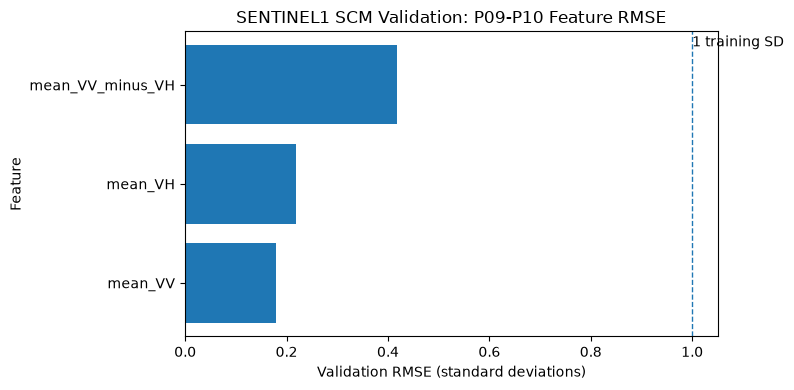

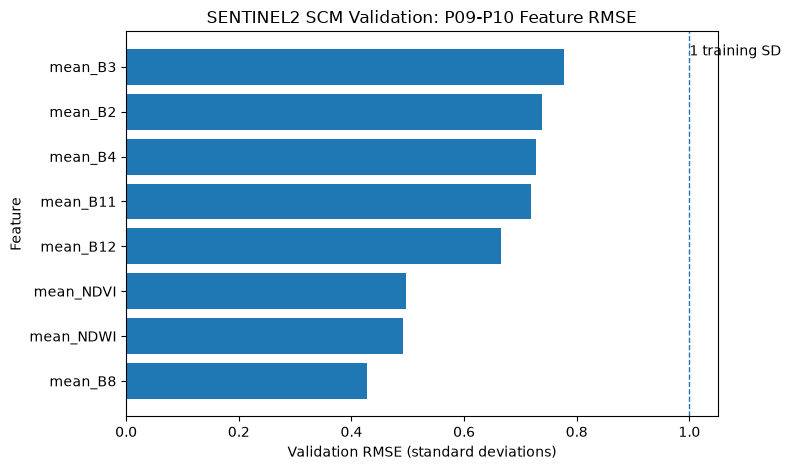

In [4]:
# =============================================================================
# 23. Visualize feature-specific validation RMSE
# =============================================================================

import matplotlib.pyplot as plt


FIGURE_DIR = (
    OUTPUT_DIR /
    "figures"
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


for sensor in [
    "sentinel1",
    "sentinel2",
]:

    plot_data = (
        feature_rmse_summary
        .loc[
            feature_rmse_summary[
                "sensor"
            ]
            ==
            sensor
        ]
        .sort_values(
            "mean_validation_rmse",
            ascending=True,
        )
        .copy()
    )


    if plot_data.empty:

        continue


    fig, ax = plt.subplots(
        figsize=(
            8,
            max(
                4,
                len(plot_data) * 0.6,
            ),
        )
    )


    ax.barh(
        plot_data[
            "feature"
        ],
        plot_data[
            "mean_validation_rmse"
        ],
    )


    ax.set_xlabel(
        "Validation RMSE (standard deviations)"
    )


    ax.set_ylabel(
        "Feature"
    )


    ax.set_title(
        f"{sensor.upper()} SCM Validation: "
        "P09-P10 Feature RMSE"
    )


    ax.axvline(
        1,
        linestyle="--",
        linewidth=1,
    )


    ax.text(
        1,
        len(plot_data) - 0.5,
        "1 training SD",
        va="top",
        ha="left",
    )


    plt.tight_layout()


    figure_file = (
        FIGURE_DIR /
        f"{sensor}_feature_validation_rmse.png"
    )


    plt.savefig(
        figure_file,
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()


    plt.close()

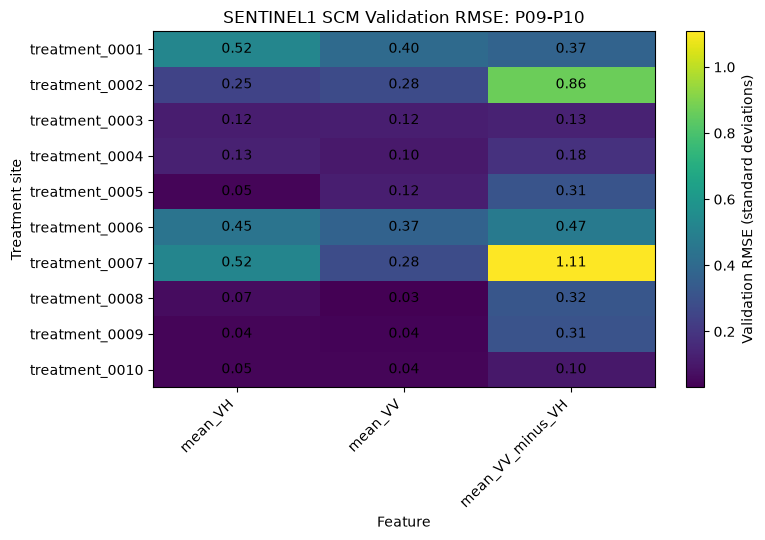

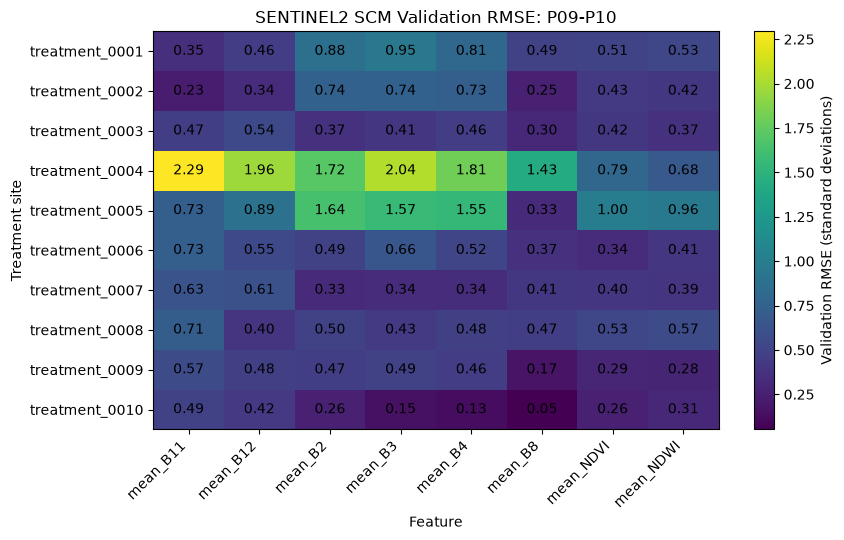

In [5]:
# =============================================================================
# 24. Treatment × feature validation RMSE heatmaps
# =============================================================================

for sensor in [
    "sentinel1",
    "sentinel2",
]:

    heatmap_data = (
        feature_validation_rmse
        .loc[
            feature_validation_rmse[
                "sensor"
            ]
            ==
            sensor
        ]
        .pivot(
            index=
                "treatment_site",

            columns=
                "feature",

            values=
                "validation_rmse",
        )
    )


    if heatmap_data.empty:

        continue


    fig, ax = plt.subplots(
        figsize=(
            max(
                8,
                heatmap_data.shape[1] * 1.1,
            ),
            max(
                5,
                heatmap_data.shape[0] * 0.55,
            ),
        )
    )


    image = ax.imshow(
        heatmap_data.values,
        aspect="auto",
    )


    ax.set_xticks(
        np.arange(
            heatmap_data.shape[1]
        )
    )


    ax.set_xticklabels(
        heatmap_data.columns,
        rotation=45,
        ha="right",
    )


    ax.set_yticks(
        np.arange(
            heatmap_data.shape[0]
        )
    )


    ax.set_yticklabels(
        heatmap_data.index
    )


    ax.set_xlabel(
        "Feature"
    )


    ax.set_ylabel(
        "Treatment site"
    )


    ax.set_title(
        f"{sensor.upper()} SCM Validation RMSE: "
        "P09-P10"
    )


    # Add RMSE number to every cell
    for i in range(
        heatmap_data.shape[0]
    ):

        for j in range(
            heatmap_data.shape[1]
        ):

            value = (
                heatmap_data.iloc[
                    i,
                    j,
                ]
            )


            if pd.notna(
                value
            ):

                ax.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                )


    colorbar = fig.colorbar(
        image,
        ax=ax,
    )


    colorbar.set_label(
        "Validation RMSE (standard deviations)"
    )


    plt.tight_layout()


    output_file = (
        FIGURE_DIR /
        f"{sensor}_treatment_feature_rmse_heatmap.png"
    )


    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()


    plt.close()